In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Setting to make numbers easier to read on display
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns on output
pd.set_option('display.max_columns', 999)

```python
import pandas as pd
```

Used to work with tables/data analysis using Pandas.

```python
import matplotlib.pyplot as plt
```

Used to create charts and graphs.

```python
import seaborn as sns
```

Used for advanced and beautiful data visualizations.

```python
from sklearn.cluster import KMeans
```

Imports KMeans algorithm for clustering/grouping similar data.

```python
from sklearn.metrics import silhouette_score
```

Used to measure how good the clusters are.

```python
from sklearn.preprocessing import StandardScaler
```

Used to scale/normalize data before machine learning.

```python
pd.options.display.float_format = '{:20.2f}'.format
```

Displays numbers in clean decimal format instead of scientific notation.

Example:

```python
12345.6789 → 12345.68
```

```python
pd.set_option('display.max_columns', 999)
```

Shows all columns in the dataset output instead of hiding some columns.


# DATA EXPLORATION

In [2]:

df = pd.read_excel("./data/online_retail_II.xlsx", sheet_name=0)

df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


### What Happens
- Reads the online retail Excel dataset.
- Stores data in a DataFrame called `df`.
- Displays first 10 rows of data.

### Insight
- Understands dataset structure and columns.
- Checks customer, product, quantity, and price details.
- Helps identify data issues early.

### Outcome
- Dataset loaded successfully.
- Initial data overview completed.
- Ready for cleaning and analysis.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


### What Happens
- Displays dataset structure and summary information.
- Shows columns, data types, null values, and memory usage.

### Insight
- Dataset contains 525K+ transaction records.
- `Customer ID` and `Description` have missing values.
- `InvoiceDate` is already in datetime format for time analysis.

### Outcome
- Identified data quality issues.
- Understood dataset size and column types.
- Ready for data cleaning and preprocessing.

In [4]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845018,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


### What Happens
- Generates statistical summary of numerical columns.
- Shows count, mean, min, max, quartiles, and standard deviation.

### Insight
- Negative values in `Quantity` and `Price` may indicate returns or errors.
- Most purchases are small quantities.
- Large difference between min and max shows presence of outliers.

### Outcome
- Detected abnormal values and outliers.
- Better understanding of customer purchase behavior.
- Helped decide data cleaning steps.

In [5]:
df.describe(include='O')

C:\Users\saimm\AppData\Local\Temp\ipykernel_3932\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


### What Happens
- Generates summary statistics for object/text columns.
- Shows count, unique values, most frequent value, and frequency.

### Insight
- Dataset has 28K+ unique invoices and 4K+ products.
- Most transactions are from the United Kingdom.
- `WHITE HANGING HEART T-LIGHT HOLDER` is the most sold product.

### Outcome
- Understood categorical data distribution.
- Identified top-selling product and dominant country.
- Useful for business and sales analysis.

In [6]:
df[df["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


### What Happens
- Filters rows where `Customer ID` is missing.
- Displays first 10 records with null customer IDs.

### Insight
- Some transactions do not have customer information.
- Negative quantities and zero prices may indicate returns or invalid records.
- Missing customer IDs can affect customer segmentation analysis.

### Outcome
- Identified incomplete customer records.
- Helped decide whether to remove or handle missing values.
- Improved data cleaning strategy.

In [7]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


#### What Happens
- Filters transactions where `Quantity` is less than 0.
- Displays records with negative purchase quantities.

#### Insight
- Negative quantities usually represent product returns or cancellations.
- Invoice numbers starting with `C` indicate canceled transactions.
- These records can affect sales and revenue analysis.

#### Outcome
- Identified return/cancellation transactions.
- Helped separate valid sales from returned orders.
- Improved accuracy of customer and revenue analysis.

In [8]:
df["Invoice"] = df["Invoice"].astype("str")
df[df["Invoice"].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.00,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.00,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.00,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.00,United Kingdom


#### What Happens
- Converts `Invoice` column into string format.
- Filters invoices that do not match a 6-digit numeric pattern.

#### Insight
- Non-matching invoices mostly contain `C` at the beginning.
- These represent canceled or returned transactions.
- Around 10K records are identified as non-standard invoices.

#### Outcome
- Detected canceled invoice records.
- Helped separate valid sales transactions.
- Improved data cleaning and transaction analysis.

In [9]:
df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

<StringArray>
['', 'C', 'A']
Length: 3, dtype: str

#### What Happens
- Removes all digits from the `Invoice` column.
- Extracts only non-numeric characters from invoice IDs.
- Shows unique remaining patterns.

#### Insight
- `""` (empty) → valid numeric invoices (normal sales).
- `C` → canceled/returned transactions.
- `A` → special/adjustment entries.

#### Outcome
- Identified invoice type patterns.
- Separated normal vs abnormal transactions.
- Useful for cleaning and categorizing sales data.

In [10]:
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


#### What Happens
- Filters invoices starting with **"A"**.
- Displays special adjustment transactions.

#### Insight
- These are **bad debt adjustments** (financial corrections).
- Very high negative prices indicate accounting entries, not sales.
- `Customer ID` is missing for these records.

#### Outcome
- Identified non-sales financial adjustments.
- Separated accounting entries from real transactions.
- Important step before revenue and customer analysis.

In [11]:
df["StockCode"] = df["StockCode"].astype("str")
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',      '47503J ',
           'C3',       'SP1002',    'AMAZONFEE']
Length: 55, dtype: str

#### What Happens
- Filters `StockCode` values that are **not standard numeric codes**.
- Extracts unique non-standard product/service codes.

#### Insight
- Dataset contains non-product entries like:
  - `POST`, `DOT`, `BANK CHARGES` → shipping/charges
  - `ADJUST`, `ADJUST2` → corrections
  - `C2`, `C3`, `D` → special transaction types
  - `GIFT_*` → gift-related entries
  - `TEST001`, `TEST002` → test records
- These are **not real products**, but operational or financial entries.

#### Outcome
- Identified non-product transactions in inventory data.
- Helped separate real product sales from system/financial records.
- Improved accuracy of product-level analysis and clustering.

In [12]:
df[df["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


#### What Happens
- Filters rows where `StockCode` starts with **"DOT"**.
- Displays all DOTCOM POSTAGE transactions.

#### Insight
- These are **shipping/postage charges**, not actual products.
- No `Customer ID` present in most cases.
- High variation in price shows shipping cost differences.

#### Outcome
- Identified non-product revenue entries (shipping charges).
- Separated logistics costs from product sales.
- Improved accuracy for product-based analysis.

In [13]:

df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


#### What Happens
- Displays the first 10 rows of the dataset.
- Gives a quick preview of transaction records.

#### Insight
- Each row represents a product purchase.
- Data includes product details, quantity, price, and customer info.
- Most transactions are from the United Kingdom.

#### Outcome
- Initial understanding of dataset structure.
- Verified columns and data quality visually.
- Helps guide next steps in cleaning and analysis.

#### What Happens

* StockCode is expected to follow pattern `[0-9]{5}`, but dataset contains mixed formats.

#### Insight

| Code             | Description                                               | Action                  |
| ---------------- | --------------------------------------------------------- | ----------------------- |
| DCGS             | Valid but mixed behavior (negative qty, null customer ID) | Exclude from clustering |
| D                | Discount transactions                                     | Exclude from clustering |
| DOT              | Postage charges                                           | Exclude from clustering |
| M / m            | Manual transactions                                       | Exclude from clustering |
| C2               | Carriage transaction                                      | Exclude from clustering |
| C3               | Rare transaction type                                     | Exclude                 |
| BANK CHARGES / B | Bank charges                                              | Exclude from clustering |
| S                | Sample items                                              | Exclude from clustering |
| TESTXXX          | Test data                                                 | Exclude from clustering |
| gift__XXX        | Gift card related                                         | Exclude                 |
| PADS             | Valid product code                                        | Include                 |
| SP1002           | Special item, inconsistent                                | Exclude for now         |
| AMAZONFEE        | Fees                                                      | Exclude for now         |
| ADJUSTX          | Manual adjustments                                        | Exclude for now         |

#### Outcome

* Clear separation of **real products vs non-product/system entries**.
* Helps avoid noise in clustering and customer segmentation.
* Ensures cleaner, more reliable analysis dataset.


## DATA CLEANING

In [14]:
cleaned_df = df.copy()

#### What Happens
- Creates a duplicate copy of the original dataset.
- Stores it in a new variable `cleaned_df`.

#### Insight
- Keeps original data (`df`) unchanged.
- Allows safe cleaning and transformations.
- Prevents accidental data loss during processing.

#### Outcome
- Created a working dataset for cleaning.
- Original dataset preserved for reference.
- Safe setup for preprocessing steps.

In [15]:
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")

mask = (
    cleaned_df["Invoice"].str.match("^\\d{6}$") == True
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


#### What Happens
- Converts `Invoice` column to string type.
- Filters only valid invoices matching 6-digit numeric format.
- Removes canceled/invalid invoices (`C`, `A`, etc.).

#### Insight
- Dataset is now cleaned to include only valid sales transactions.
- Invalid entries like returns, adjustments, and charges are removed.
- Row count reduced, showing data filtering impact.

#### Outcome
- Clean dataset ready for analysis.
- Only real customer purchase records retained.
- Improved accuracy for sales and customer segmentation.

In [16]:
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype("str")

mask = (
    (cleaned_df["StockCode"].str.match("^\\d{5}$") == True)
    | (cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
    | (cleaned_df["StockCode"].str.match("^PADS$") == True)
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


#### What Happens
- Converts `StockCode` to string type.
- Filters only valid product codes:
  - 5-digit numeric codes
  - 5-digit + letter codes
  - special valid code `PADS`
- Removes non-product/system entries.

#### Insight
- Dataset is now focused on real product transactions only.
- System entries, charges, and invalid stock codes are removed.
- Slight reduction in dataset size after cleaning.

#### Outcome
- Clean product-level dataset created.
- Only valid inventory items retained.
- Ready for product analysis and customer segmentation.

In [17]:

cleaned_df.dropna(subset=["Customer ID"], inplace=True)

In [18]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.00,406337,406337.00,406337.00
mean,13.62,2010-07-01 10:11:06.543287,2.99,15373.63
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14004.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.37


In [19]:

len(cleaned_df[cleaned_df["Price"] == 0])

28

In [20]:
cleaned_df = cleaned_df[cleaned_df["Price"] > 0.0]

In [21]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.00,406309,406309.00,406309.00
mean,13.62,2010-07-01 10:14:25.869572,2.99,15373.72
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14006.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.33


In [22]:
cleaned_df["Price"].min()

np.float64(0.001)

In [23]:
len(cleaned_df)/len(df)

0.7732429238325965

# How Does K means Clustering Work?

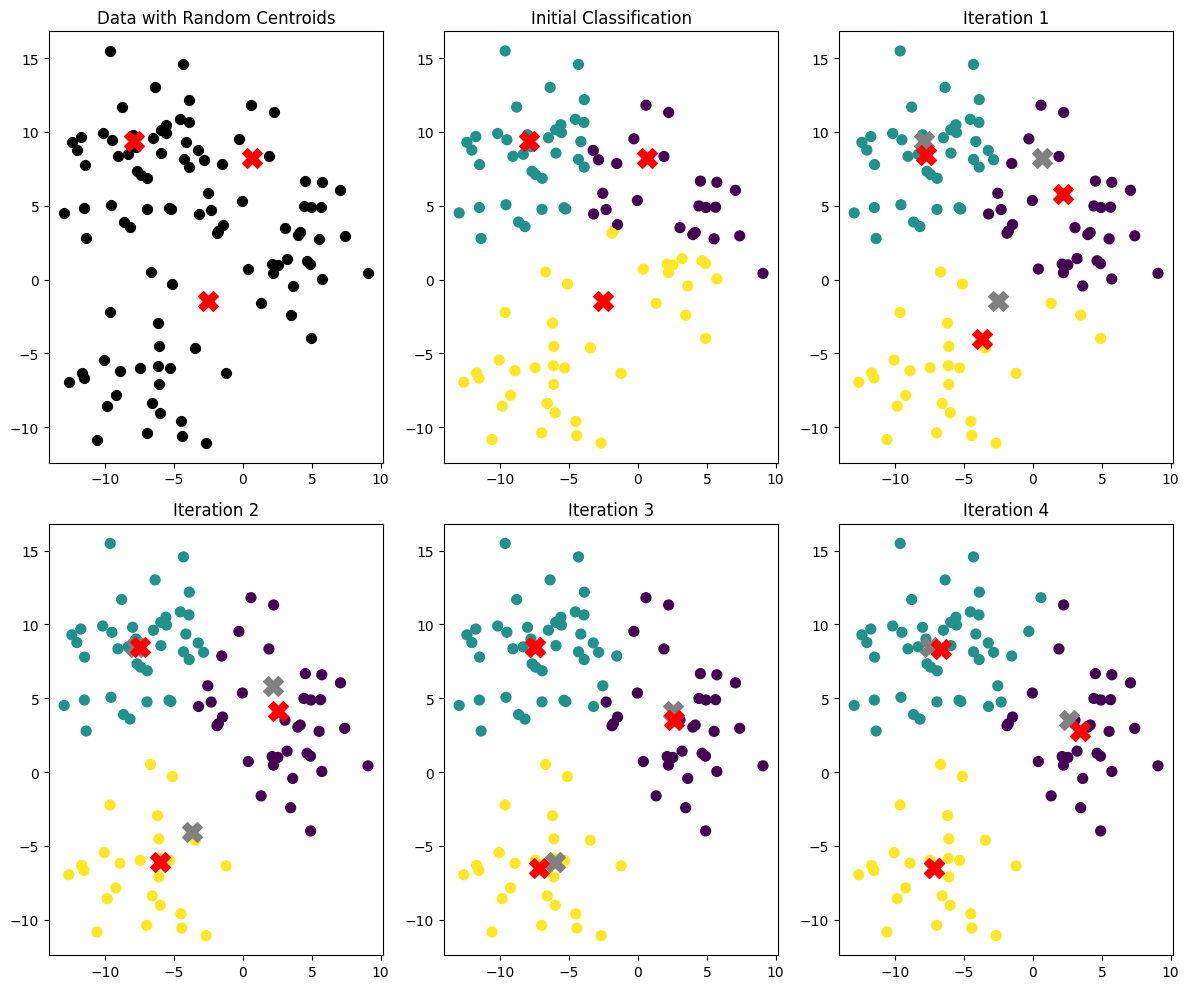

## Feature Engineering

In [25]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,7.50


#### What Happens
- Creates a new column `SalesLineTotal`.
- Calculates total value for each transaction using:
  `Quantity × Price`.

#### Insight
- Each row now shows revenue per product line.
- Negative values indicate returns or cancellations (negative sales impact).
- Allows tracking of product-level revenue contribution.

#### Outcome
- Added monetary value to each transaction.
- Enabled revenue-based analysis instead of just quantity.
- Foundation for customer segmentation and sales insights.

In [26]:

aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
    .agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,169.36,2,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,221.16,1,2010-09-27 14:59:00
3,12349.00,2221.14,2,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00


#### What Happens
- Groups data by `Customer ID`.
- Calculates customer-level metrics:
  - **MonetaryValue** = total spend per customer
  - **Frequency** = number of unique invoices (purchases)
  - **LastInvoiceDate** = most recent purchase date

#### Insight
- Converts transaction-level data into customer-level profile.
- Shows how much each customer spends and how often they buy.
- Helps identify high-value and active/inactive customers.

#### Outcome
- Built customer-level dataset for segmentation (RFM base).
- Ready for advanced analysis like clustering.
- Enables business insights on customer behavior.

In [27]:

max_invoice_date = aggregated_df["LastInvoiceDate"].max()

aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


#### What Happens
- Finds the latest purchase date in the dataset (`max_invoice_date`).
- Calculates **Recency** = number of days since each customer’s last purchase.

#### Insight
- Lower recency value = more recent customer activity.
- Higher recency value = inactive or lost customers.
- Completes the **RFM (Recency, Frequency, Monetary)** structure.

#### Outcome
- Added Recency metric for each customer.
- Built full RFM-ready dataset.
- Enabled customer behavior segmentation for clustering.

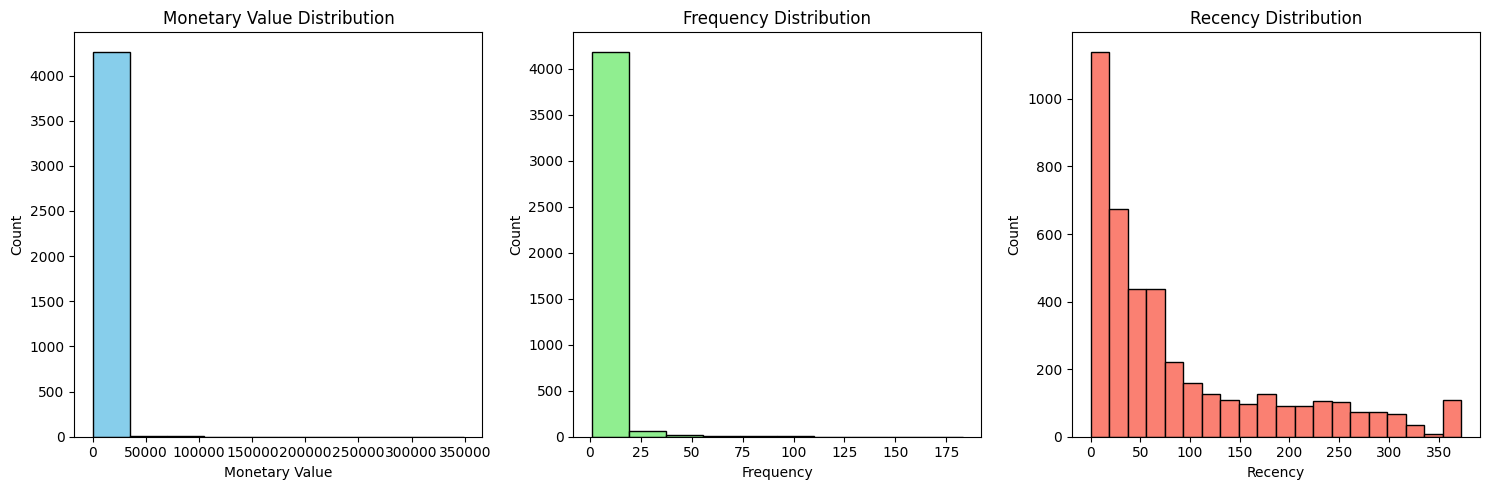

In [28]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### What Happens
- Plots histograms for RFM metrics:
  - Monetary Value (total spend per customer)
  - Frequency (number of purchases)
  - Recency (days since last purchase)
- Uses visualization to understand customer behavior distribution.

#### Insight
- **Monetary Value**: Highly skewed → few customers spend very high amounts.
- **Frequency**: Most customers purchase few times; only a small group are frequent buyers.
- **Recency**: Many customers are inactive for long periods, few are recent buyers.

#### Outcome
- Clear understanding of customer distribution patterns.
- Confirms presence of high-value outliers and inactive customers.
- Helps decide scaling and clustering strategy for RFM segmentation.

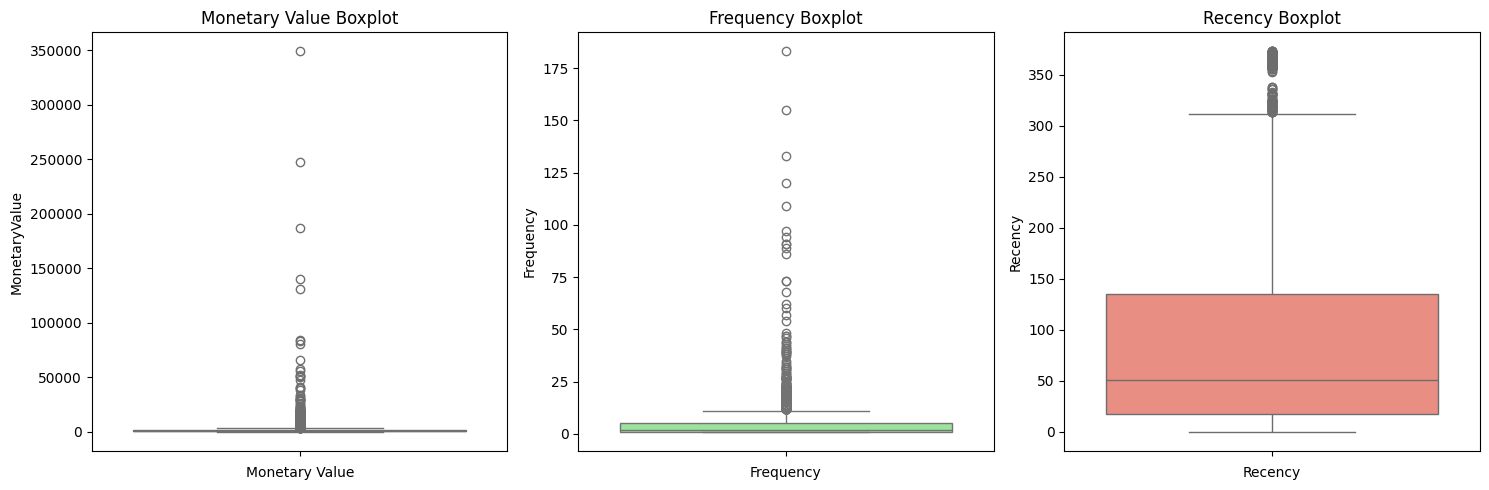

In [29]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

#### What Happens
- Creates boxplots for RFM features:
  - MonetaryValue
  - Frequency
  - Recency
- Visualizes spread, median, and outliers in each metric.

#### Insight
- **MonetaryValue** → many extreme outliers (very high spenders).
- **Frequency** → most customers buy few times, few are very frequent buyers.
- **Recency** → wide spread, showing mix of active and inactive customers.
- Strong skewness in all three features.

#### Outcome
- Identified presence of outliers in RFM data.
- Confirmed need for scaling before clustering.
- Helped understand customer behavior variability.

In [30]:

M_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1

monetary_outliers_df = aggregated_df[(aggregated_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR)) | (aggregated_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))].copy()

monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.00,423.00,423.00,423,423.00
mean,15103.04,12188.10,17.17,2010-11-09 12:26:02.978723,30.04
min,12357.00,3802.04,1.00,2009-12-10 18:03:00,0.00
25%,13622.00,4605.94,8.00,2010-11-08 13:17:30,3.00
50%,14961.00,6191.32,12.00,2010-11-26 12:19:00,13.00
75%,16692.00,10273.24,18.00,2010-12-06 10:34:30,31.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,364.00
std,1728.66,25830.85,19.73,NaN,51.54


#### What Happens
- Calculates IQR (Interquartile Range) for `MonetaryValue`.
- Detects customers with unusually high or low spending.
- Stores detected outliers in `monetary_outliers_df`.

#### Insight
- 423 customers identified as monetary outliers.
- Some customers spend extremely high amounts compared to others.
- Large gap between mean and max confirms heavy spending skewness.

#### Outcome
- Identified high-value customer outliers.
- Helped understand spending behavior extremes.
- Supports decisions for scaling or outlier treatment before clustering.

In [31]:

F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1

frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) | (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()

frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,15352.66,14409.71,23.81,2010-11-23 11:06:20.645161,16.09
min,12437.00,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,13800.00,4331.56,13.00,2010-11-20 13:14:30,2.00
50%,15465.00,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,16828.50,11692.41,23.00,2010-12-07 11:08:30,19.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,211.00
std,1748.43,31381.74,21.93,NaN,26.59


#### What Happens
- Calculates IQR for `Frequency`.
- Detects customers with unusually high or low purchase frequency.
- Stores frequency outliers in `frequency_outliers_df`.

#### Insight
- 279 customers identified as frequency outliers.
- Some customers purchase significantly more often than others.
- High-frequency customers are likely loyal or business buyers.

#### Outcome
- Identified highly active customer groups.
- Highlighted extreme purchasing behavior.
- Useful for customer segmentation and loyalty analysis.

In [32]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers_df.index))]

non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.00,3809.00,3809.00,3809,3809.00
mean,15376.48,885.50,2.86,2010-09-03 11:16:46.516146,97.08
min,12346.00,1.55,1.00,2009-12-01 10:49:00,0.00
25%,13912.00,279.91,1.00,2010-07-08 14:48:00,22.00
50%,15389.00,588.05,2.00,2010-10-12 16:25:00,58.00
75%,16854.00,1269.05,4.00,2010-11-17 13:14:00,154.00
max,18287.00,3788.21,11.00,2010-12-09 20:01:00,373.00
std,1693.20,817.67,2.24,NaN,98.11


#### What Happens
- Removes monetary and frequency outlier customers from the dataset.
- Creates `non_outliers_df` containing normal customer behavior only.

#### Insight
- Majority customers have low-to-moderate spending and purchase frequency.
- Data distribution becomes more balanced after removing extremes.
- Reduced skewness improves clustering performance.

#### Outcome
- Created cleaner dataset for machine learning.
- Reduced impact of extreme customer behavior.
- Improved reliability of customer segmentation analysis.

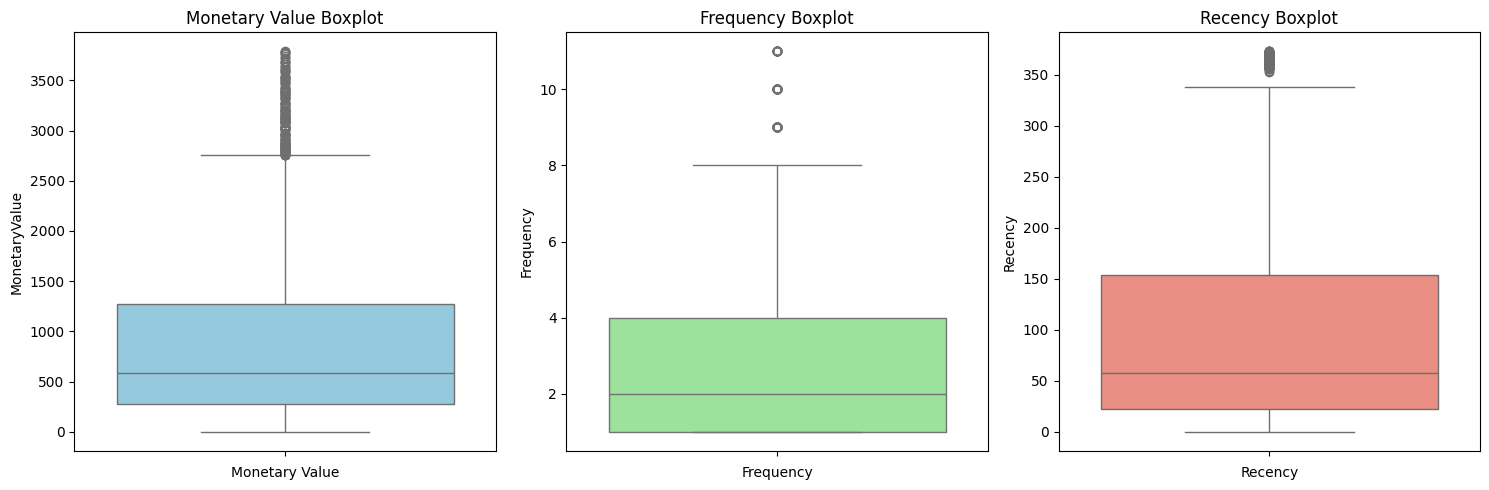

In [33]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

#### What Happens
- Creates boxplots for RFM metrics after removing outliers.
- Visualizes cleaned customer behavior distribution.

#### Insight
- MonetaryValue and Frequency are now less skewed.
- Most extreme customer values have been removed.
- Recency still shows some inactive customer outliers.

#### Outcome
- Cleaner and more balanced dataset achieved.
- Reduced outlier impact on clustering.
- Improved data quality for machine learning analysis.

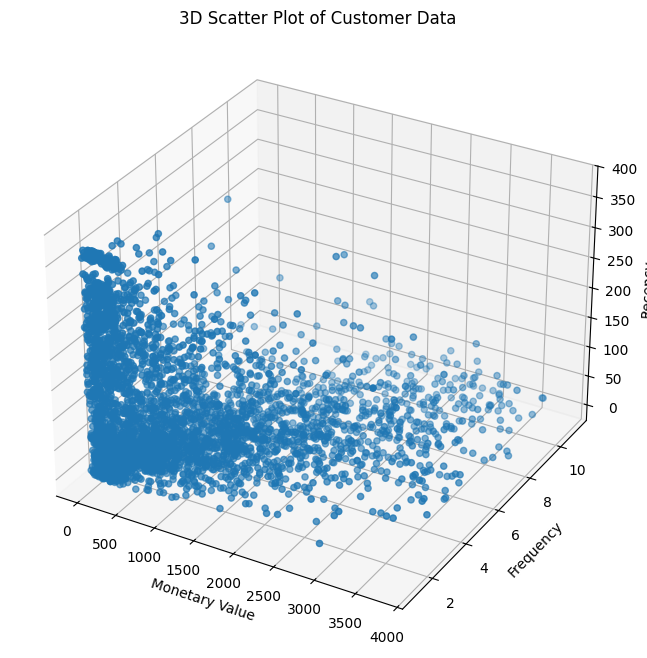

In [34]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(non_outliers_df["MonetaryValue"], non_outliers_df["Frequency"], non_outliers_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

#### What Happens
- Creates a 3D scatter plot using:
  - MonetaryValue (X-axis)
  - Frequency (Y-axis)
  - Recency (Z-axis)
- Visualizes customer distribution in RFM space.

#### Insight
- Customers form visible behavior patterns/groups.
- Most customers have low frequency and low spending.
- Some customers show high spending or recent activity.
- Data appears suitable for clustering analysis.

#### Outcome
- Visual understanding of customer segmentation patterns.
- Confirmed variation in customer behavior.
- Prepared data for KMeans clustering.

In [35]:

scaler = StandardScaler()

scaled_data = scaler.fit_transform(non_outliers_df[["MonetaryValue", "Frequency", "Recency"]])

scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]], shape=(3809, 3))

#### What Happens
- Creates a `StandardScaler` object.
- Standardizes RFM features:
  - MonetaryValue
  - Frequency
  - Recency
- Converts values into scaled numerical format.

#### Insight
- Features originally had very different ranges.
- Scaling prevents large-value features from dominating clustering.
- Scaled data now has balanced influence across all variables.

#### Outcome
- Prepared normalized dataset for machine learning.
- Improved clustering accuracy and performance.
- Generated scaled RFM feature matrix for KMeans.

In [36]:

scaled_data_df = pd.DataFrame(scaled_data, index=non_outliers_df.index, columns=("MonetaryValue", "Frequency", "Recency"))

scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.88,-0.38,0.68
1,0.54,-0.38,-0.97
2,-0.81,-0.83,-0.25
3,1.63,-0.38,-0.56
4,-0.72,-0.83,-0.89
...,...,...,...
4280,-0.30,1.40,-0.82
4281,-0.58,-0.83,-0.32
4282,-0.62,-0.83,2.02
4283,0.44,-0.38,0.14


#### What Happens
- Converts scaled RFM array into a Pandas DataFrame.
- Assigns column names:
  - MonetaryValue
  - Frequency
  - Recency

#### Insight
- Scaled values are now easier to read and analyze.
- Negative values = below average customer behavior.
- Positive values = above average customer behavior.

#### Outcome
- Created structured scaled dataset.
- Improved readability for clustering analysis.
- Ready for KMeans model training.

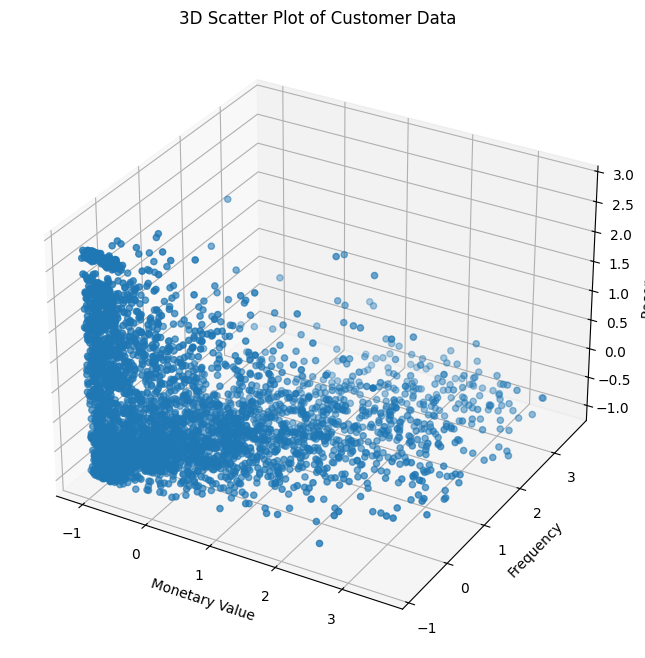

In [37]:

fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(scaled_data_df["MonetaryValue"], scaled_data_df["Frequency"], scaled_data_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

#### What Happens
- Creates a 3D graph using scaled customer data:
  - Spending (MonetaryValue)
  - Purchase count (Frequency)
  - Last purchase activity (Recency)

#### Insight
- After scaling, all features are on the same level/range.
- Customers with similar behavior appear closer together.
- Different customer behavior groups are easier to notice.

#### Outcome
- Data became balanced and easier for machine learning to understand.
- Improved customer pattern visibility.
- Data is now ready for accurate KMeans clustering.


# KMeans Clustering

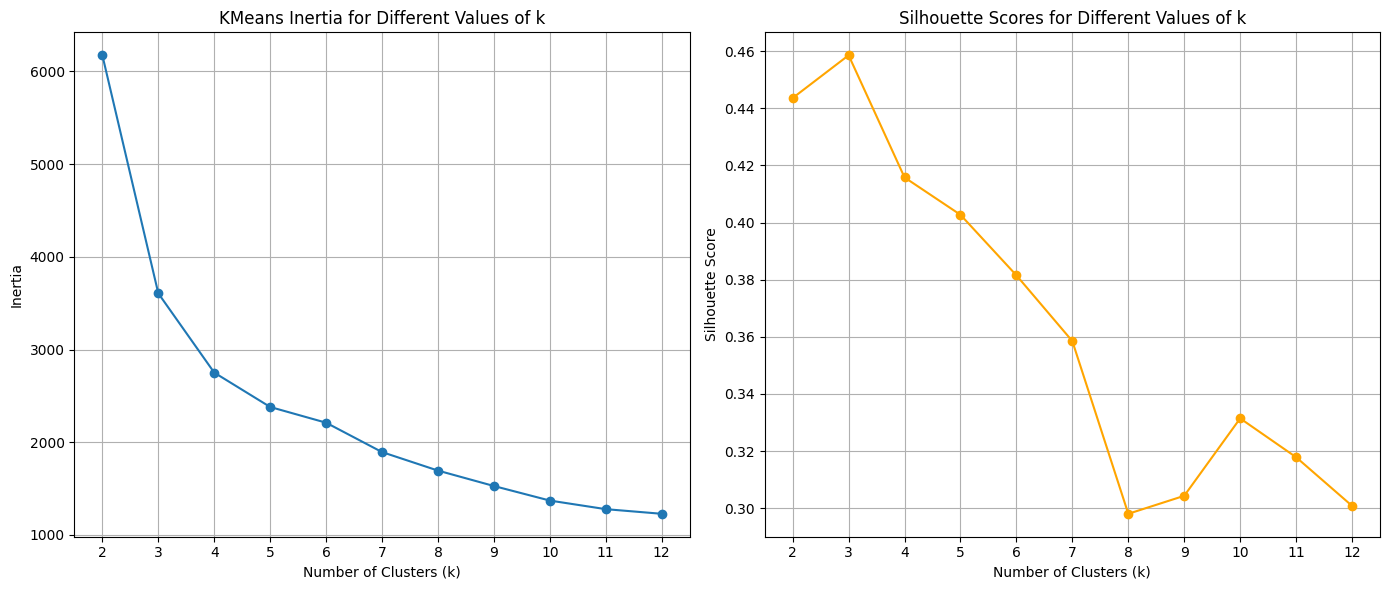

In [ ]:

max_k = 12

inertia = []
silhoutte_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(scaled_data_df)

    sil_score = silhouette_score(scaled_data_df, cluster_labels)

    silhoutte_scores.append(sil_score)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhoutte_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

#### What Happens
- Runs KMeans clustering for different cluster values (`k = 2 to 12`).
- Calculates:
  - **Inertia** → measures cluster compactness.
  - **Silhouette Score** → measures cluster quality.
- Plots both metrics to find the best number of clusters.

#### Insight
- Inertia decreases as clusters increase (normal behavior).
- Biggest improvement happens around lower k values.
- Silhouette score is highest near **k = 3**, meaning customer groups are most clearly separated there.
- After some point, adding more clusters gives weaker improvement.

#### Outcome
- Identified optimal cluster range for customer segmentation.
- Helped choose best `k` value for KMeans.
- Prepared final clustering model with better accuracy.

In [39]:
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=1000)

cluster_labels = kmeans.fit_predict(scaled_data_df)

cluster_labels

array([1, 0, 2, ..., 1, 0, 0], shape=(3809,), dtype=int32)

#### What Happens
- Creates a KMeans model with `4` clusters.
- Trains the model using scaled RFM data.
- Assigns a cluster label to each customer.

#### Insight
- Customers are grouped based on similar spending, purchase frequency, and recency behavior.
- Each number (`0, 1, 2, 3`) represents a different customer segment.
- Similar customers fall into the same cluster.

#### Outcome
- Customer segmentation completed successfully.
- Generated cluster labels for all customers.
- Ready for cluster analysis and business interpretation.

In [40]:
non_outliers_df["Cluster"] = cluster_labels

non_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.00,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.00,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.00,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.00,1246.43,2,2010-08-20 11:57:00,111,0


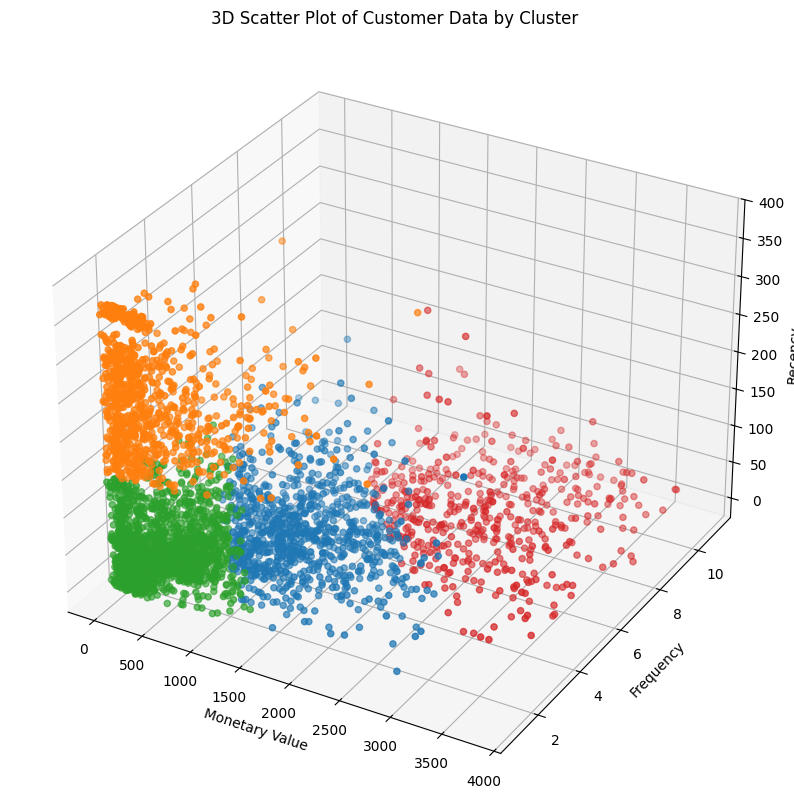

In [41]:

cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728'}  # Red

colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'], 
                     non_outliers_df['Frequency'], 
                     non_outliers_df['Recency'], 
                     c=colors,  # Use mapped solid colors
                     marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

#### What Happens

- Defines a custom color for each customer cluster:
  - Cluster 0 → Blue
  - Cluster 1 → Orange
  - Cluster 2 → Green
  - Cluster 3 → Red

- Maps cluster labels to colors:
  ```python
  colors = non_outliers_df['Cluster'].map(cluster_colors)
  ```

- Creates a 3D scatter plot using:
  - `MonetaryValue` → Customer spending
  - `Frequency` → Number of purchases
  - `Recency` → Days since last purchase

- Each point represents one customer.
- Colors show which cluster the customer belongs to.

#### Insight

- Customers with similar buying behavior appear close together.
- Different colors represent different customer segments.
- Visualization helps understand differences in:
  - Spending behavior
  - Purchase frequency
  - Customer activity level

- Example:
  - High spending + frequent purchases + recent activity  
    → Loyal/high-value customers
  - Low spending + few purchases + inactive for long time  
    → Low-engagement customers

- Confirms that KMeans clustering separated customers into meaningful groups.

#### Outcome

- Created visual customer segmentation.
- Made cluster behavior easier to understand and explain.
- Helps businesses identify:
  - Loyal customers
  - High spenders
  - Inactive customers
  - Occasional buyers

- Useful for:
  - Targeted marketing
  - Customer retention
  - Personalized offers
  - Business decision-making

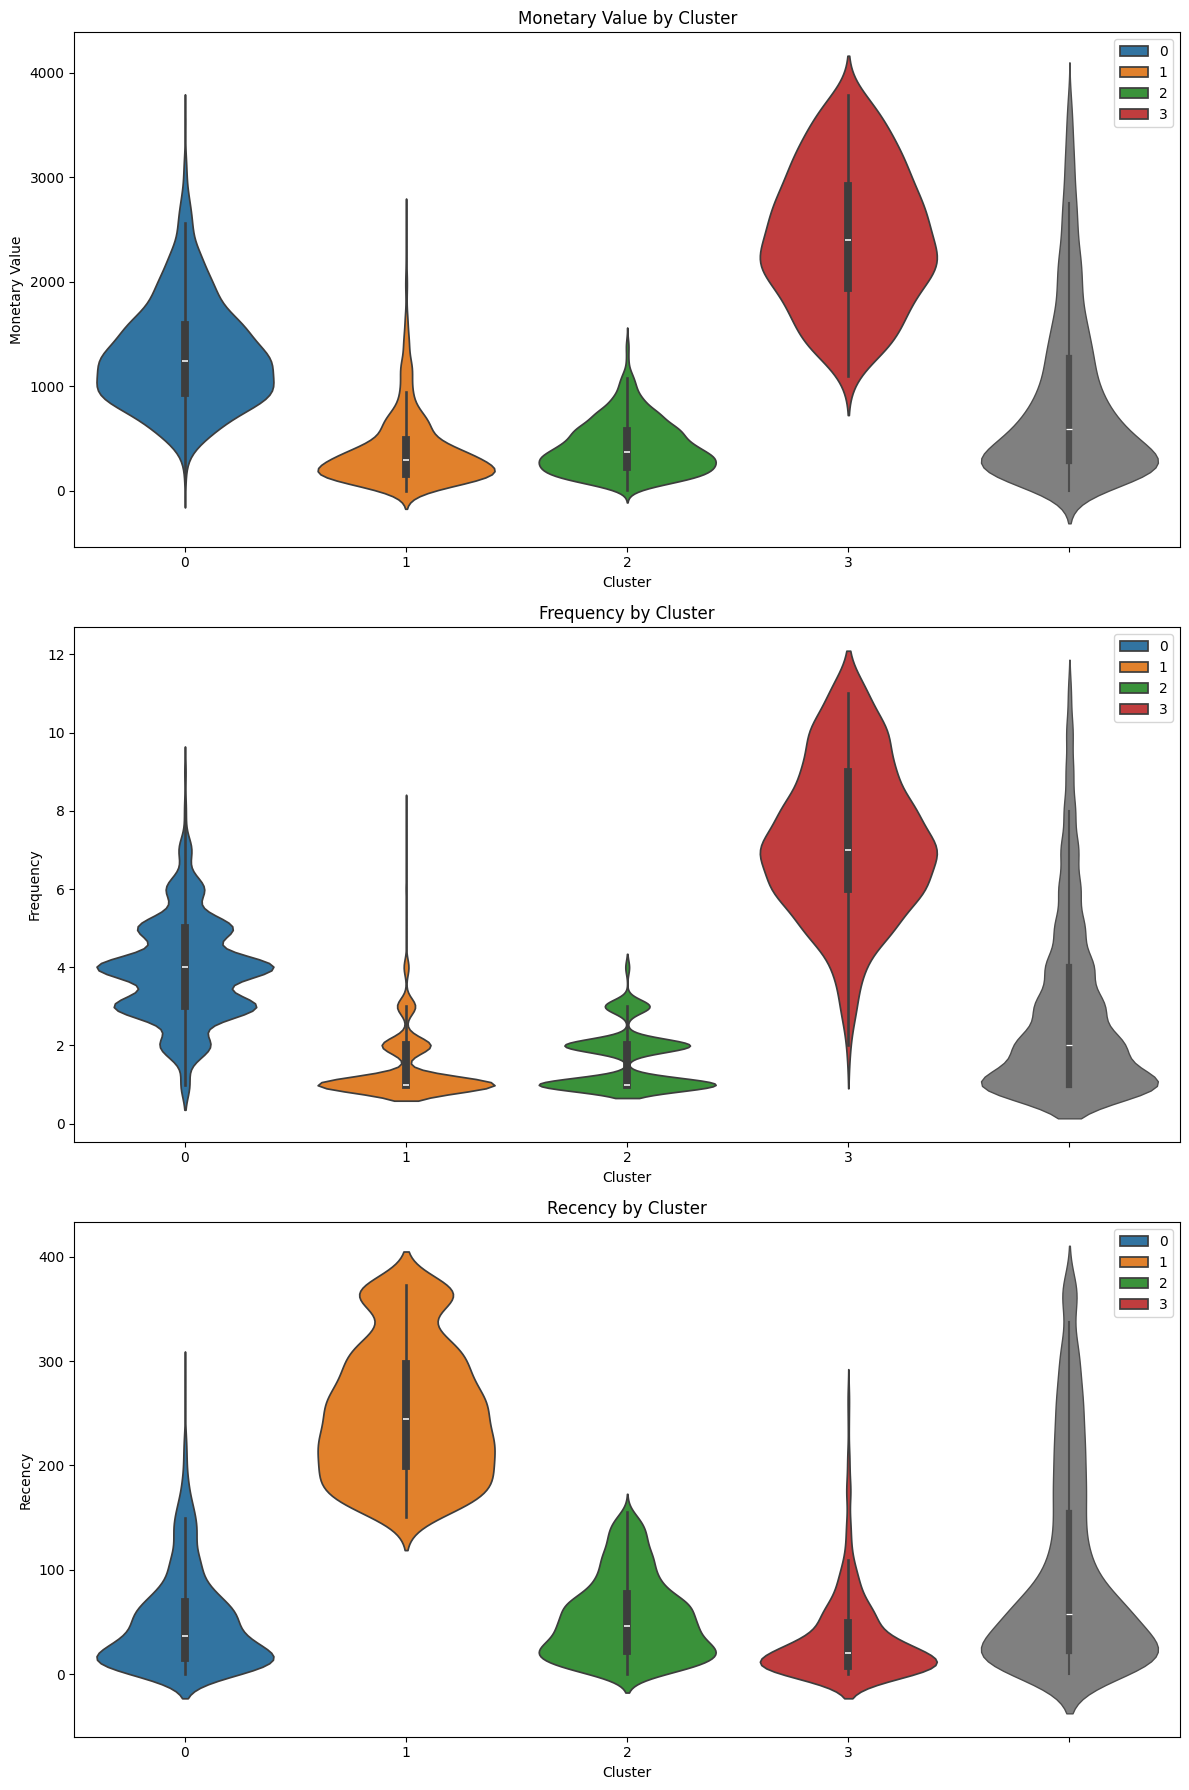

In [42]:

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')


plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

#### What Happens

- Creates violin plots for each RFM metric:
  - MonetaryValue
  - Frequency
  - Recency

- Compares the distribution of values across customer clusters.
- Uses different colors for each cluster.
- Adds an overall gray violin plot as a reference for total dataset distribution.

- Each violin plot shows:
  - Data spread
  - Density/distribution
  - Median and variation within clusters

#### Insight

- Helps compare customer behavior between clusters.
- Shows which clusters:
  - Spend more money
  - Purchase more frequently
  - Are more recently active

- Wider violin sections indicate higher concentration of customers in that value range.
- Narrow sections indicate fewer customers.

- Example observations:
  - Some clusters may have high spending but low frequency.
  - Some clusters may contain inactive customers with high recency values.
  - Certain clusters show tightly grouped behavior while others are more varied.

- Gray violin plot helps compare each cluster against overall customer distribution.

#### Outcome

- Clearly visualized differences between customer segments.
- Improved understanding of cluster characteristics.
- Helped interpret customer behavior patterns for business decisions.

- Useful for:
  - Identifying loyal customers
  - Finding inactive customers
  - Creating personalized marketing strategies
  - Customer retention planning

In [43]:

overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])

outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.00,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.00,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.00,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.00,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.00,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


#### What Happens

- Finds customers who are outliers in both:
  - MonetaryValue
  - Frequency

```python
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)
```

- Separates outliers into 3 groups:
  - Monetary-only outliers
  - Frequency-only outliers
  - Customers who are outliers in both metrics

```python
monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]
```

- Assigns custom cluster labels:
  - `-1` → Monetary outliers only
  - `-2` → Frequency outliers only
  - `-3` → Both monetary and frequency outliers

- Combines all outlier groups into one dataset:
  ```python
  outlier_clusters_df = pd.concat([...])
  ```

#### Insight

- Some customers spend unusually high amounts but purchase less often.
- Some customers purchase very frequently compared to normal customers.
- Customers in cluster `-3` are extremely valuable:
  - High spending
  - High purchase frequency

- These customers behave very differently from average customers.
- Including them in normal clustering could distort KMeans results.

#### Outcome

- Successfully isolated extreme customer behaviors.
- Preserved valuable outlier customers for separate business analysis.
- Improved quality and stability of main customer segmentation model.

- Helps businesses identify:
  - VIP customers
  - Bulk buyers
  - High-frequency loyal customers
  - Special handling customer groups

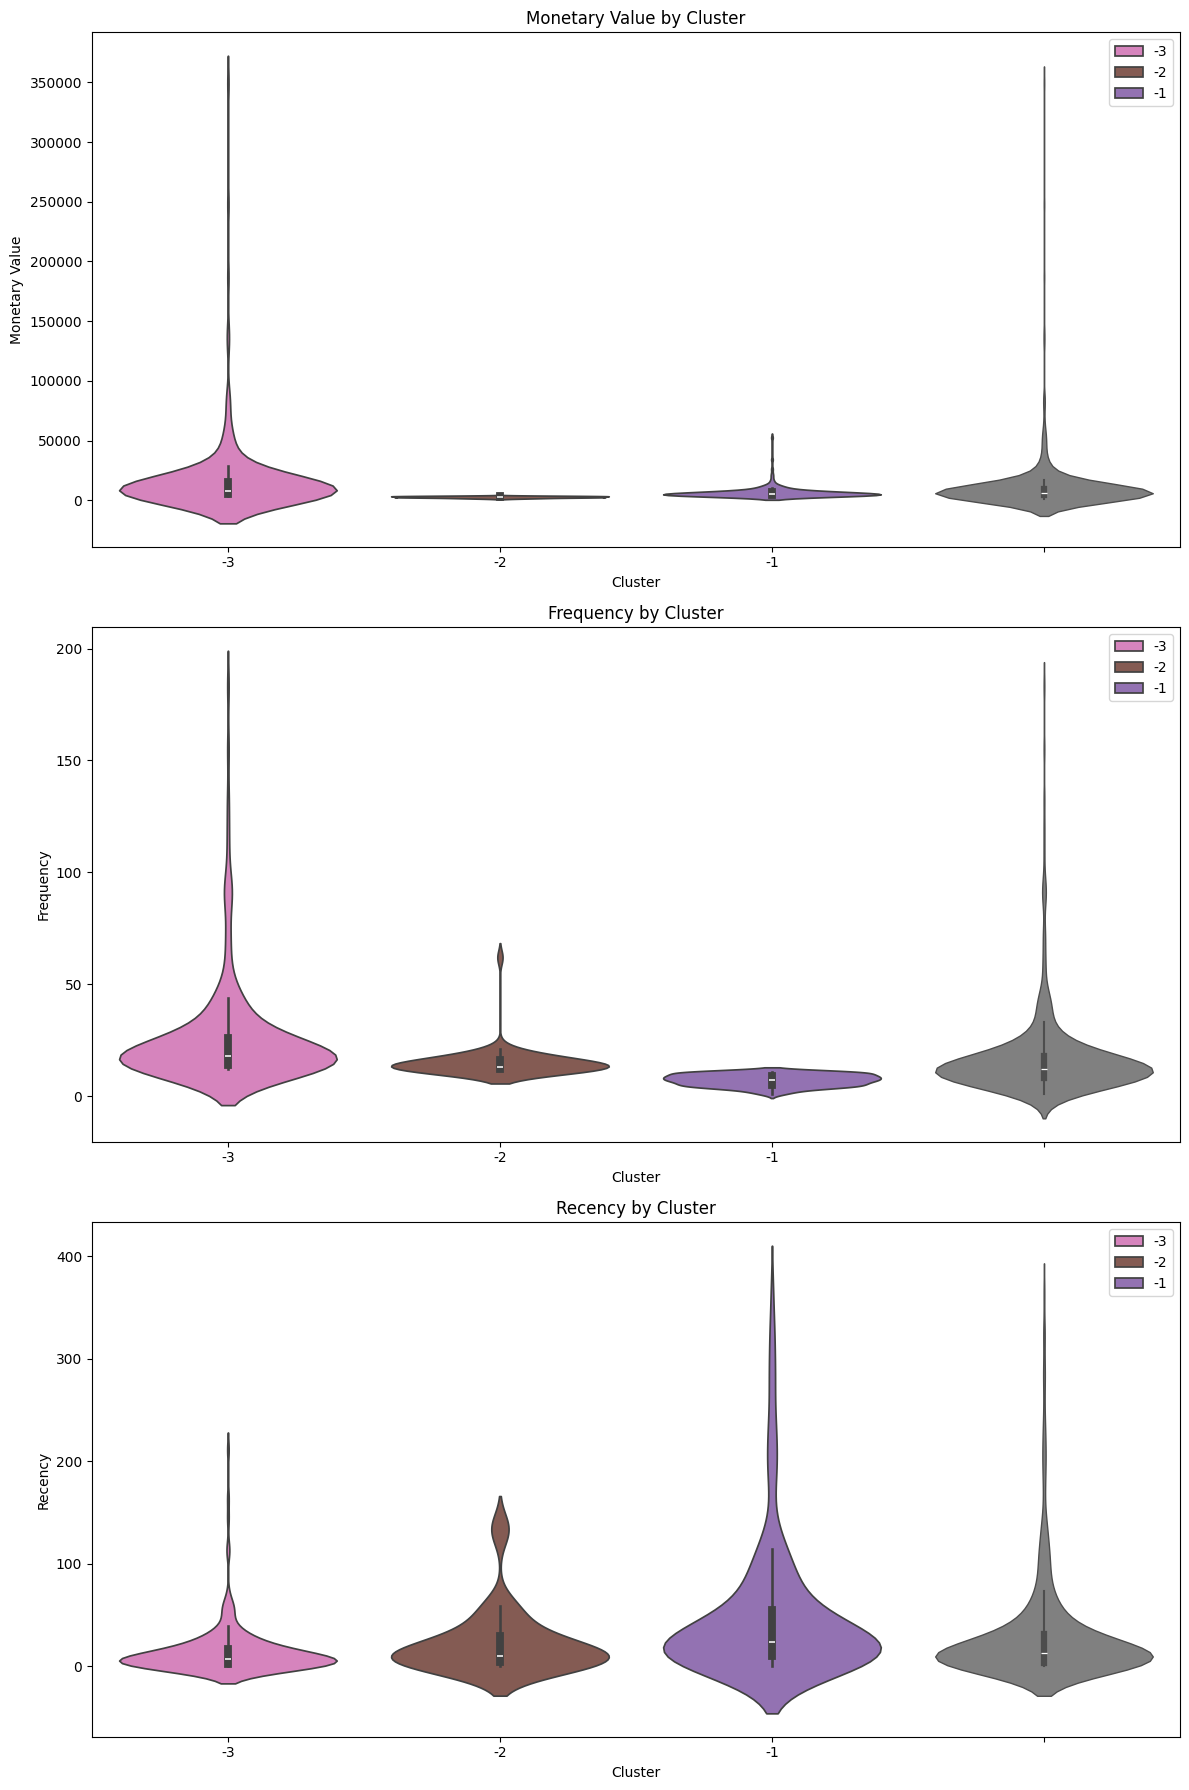

In [44]:

cluster_colors = {-1: '#9467bd',
                  -2: '#8c564b',
                  -3: '#e377c2'}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

#### What Happens

- Defines custom colors for outlier clusters:
  - `-1` → Monetary-only outliers
  - `-2` → Frequency-only outliers
  - `-3` → Both monetary and frequency outliers

- Creates violin plots for:
  - MonetaryValue
  - Frequency
  - Recency

- Compares behavior of different outlier customer groups.
- Uses gray violin plots as reference for overall distribution.

#### Insight

- Cluster `-1` customers spend unusually high amounts compared to others.
- Cluster `-2` customers purchase very frequently.
- Cluster `-3` customers are extreme in both:
  - High spending
  - High purchase frequency

- Violin shape shows:
  - Customer density
  - Spread of values
  - Distribution pattern inside each outlier group

- Some outlier customers are highly active and valuable to the business.

#### Outcome

- Visualized extreme customer behavior separately from normal customers.
- Improved understanding of VIP and high-value customer groups.
- Helped analyze special customer segments without affecting normal clustering.

- Useful for:
  - VIP customer targeting
  - Loyalty programs
  - Premium marketing campaigns
  - High-value customer retention

In [45]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

#### What Happens

- Creates meaningful business names for each customer cluster.
- Replaces numeric cluster IDs with understandable customer segment labels.

```python
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}
```

#### Insight

- Each label represents a different customer behavior type:
  - **RETAIN** → Valuable active customers to keep engaged
  - **RE-ENGAGE** → Inactive customers needing attention
  - **NURTURE** → New/low-engagement customers with growth potential
  - **REWARD** → Loyal customers deserving rewards
  - **PAMPER** → High-spending customers needing premium treatment
  - **UPSELL** → Frequent buyers with upselling opportunity
  - **DELIGHT** → Top-tier customers with very high value and activity

- Business-friendly names make cluster interpretation easier.

#### Outcome

- Converted technical clusters into actionable business segments.
- Improved communication of customer insights to non-technical stakeholders.
- Enabled targeted marketing and customer strategy planning.

In [46]:

full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


In [47]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1,RE-ENGAGE
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0,RETAIN
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2,NURTURE
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0,RETAIN
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2,NURTURE
...,...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3,DELIGHT


#### What Happens

- Adds a new column called `ClusterLabel`.
- Maps numeric cluster IDs to meaningful business segment names using:

```python
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)
```

- Each customer now has:
  - Cluster number
  - Business-friendly segment label

#### Insight

- Customers are now grouped into understandable business categories instead of numeric IDs.
- Makes customer behavior easier to analyze and explain.

- Example:
  - `RETAIN` → Active valuable customers
  - `RE-ENGAGE` → Inactive customers
  - `NURTURE` → Low-engagement customers
  - `REWARD` → Loyal customers
  - `DELIGHT` → Top-value customers

- Helps connect machine learning results to real business actions.

#### Outcome

- Final customer segmentation dataset created.
- Improved readability and business interpretation.
- Enabled actionable marketing and retention strategies.

- Useful for:
  - Personalized campaigns
  - Customer retention
  - Loyalty programs
  - Revenue growth strategies

# Visualisation


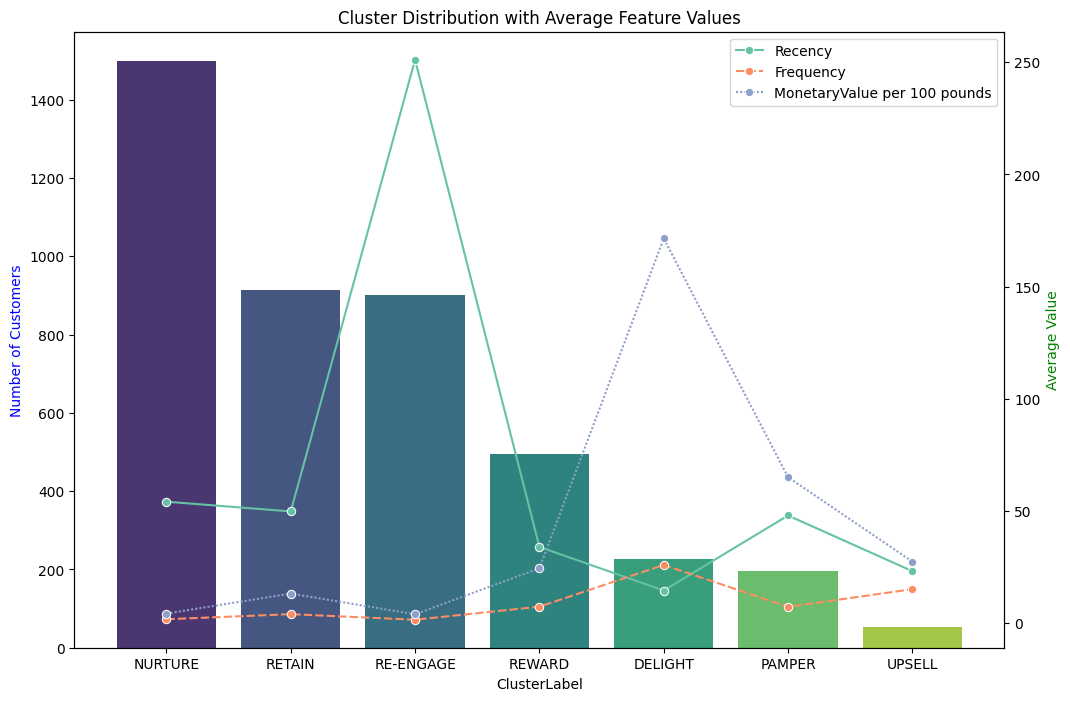

In [48]:

cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()

#### What Happens

- Counts number of customers in each customer segment:
  ```python
  cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
  ```

- Creates a new feature:
  ```python
  MonetaryValue per 100 pounds
  ```
  to make monetary values easier to visualize.

- Calculates average values of:
  - Recency
  - Frequency
  - MonetaryValue

  for each customer segment.

- Creates:
  - **Bar chart** → Number of customers in each segment
  - **Line chart** → Average RFM values for each segment

#### Insight

- Bar chart shows which customer groups are largest or smallest.
- Line chart compares customer behavior across segments.

- Helps identify:
  - Most active customers
  - Highest spending customers
  - Most inactive customers
  - Most frequent buyers

- Example:
  - `DELIGHT` customers likely show:
    - High spending
    - High frequency
    - Low recency (recent activity)

  - `RE-ENGAGE` customers may show:
    - High recency
    - Low frequency
    - Lower spending

- Combining both charts gives both:
  - Customer count
  - Customer quality/behavior

#### Outcome

- Created business-level summary of customer segments.
- Improved understanding of customer distribution and value.
- Helped compare behavior between all customer groups.

- Useful for:
  - Marketing strategy
  - Customer prioritization
  - Revenue optimization
  - Retention planning
  